## RNN vs LSTM
#### This code module compares the performance of a vanilla RNN vs. LSTM on a classifier. LSTMs are known to mitigate the vanishing gradient problem (which is prevalent in vanilla RNNs) by employing cell state with gates which control the information flow. 
#### The following code does a comparative study of the performance of RNNs and LSTMs on a classification problem. 

### Import libraries

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.metrics import accuracy_score
from torch.utils.data import DataLoader, TensorDataset, random_split

In [2]:
# set seed for reproducibility
torch.manual_seed(42)

### Set initial parameters

In [ ]:
# Define input/output sizes and model settings
input_size = 10        # Size of each element in the sequence
seq_length = 5         # Number of time steps
hidden_size = 32       # Hidden state size for RNN/LSTM
num_classes = 2        # Binary classification
batch_size = 32
num_epochs = 200
learning_rate = 0.001

### Generate synthetic data

In [ ]:
# Generate synthetic inputs (1000 sequences of shape [seq_len, input_size])
num_samples = 10000
X = torch.randn(num_samples, seq_length, input_size)

# Generate binary labels randomly
y = torch.randint(0, num_classes, (num_samples,))

# Create a TensorDataset and split into training and validation sets
dataset = TensorDataset(X, y)
train_size = int(0.8 * len(dataset))
train_ds, val_ds = random_split(dataset, [train_size, len(dataset) - train_size])
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size)


### Model definitions

In [18]:
# RNN-based Classifier
class RNNClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super().__init__()
        # Single-layer RNN
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        # Fully connected layer for final classification
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # Pass input through RNN
        out, _ = self.rnn(x)  # out shape: [batch, seq_len, hidden_size]
        out = out[:, -1, :]   # Take the output from the last time step
        return self.fc(out)   # Pass to output layer

# LSTM-based Classifier
class LSTMClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super().__init__()
        # Single-layer LSTM
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        # Fully connected layer for classification
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # Pass input through LSTM
        out, _ = self.lstm(x)  # out shape: [batch, seq_len, hidden_size]
        out = out[:, -1, :]    # Use last time step
        return self.fc(out)


### Training and Evaluation function

In [ ]:
def train_model(model, loader, optimizer, loss_fn):
    model.train()  # Set model to training mode
    for xb, yb in loader:
        optimizer.zero_grad()
        preds = model(xb)               # Forward pass
        loss = loss_fn(preds, yb)       # Compute loss
        loss.backward()                 # Backpropagation
        optimizer.step()                # Update weights

def evaluate_model(model, loader):
    model.eval()  # Set model to evaluation mode
    all_preds, all_labels = [], []
    with torch.no_grad():  # Disable gradient computation
        for xb, yb in loader:
            preds = model(xb)
            pred_labels = preds.argmax(dim=1)  # Choose the class with max logit
            all_preds.extend(pred_labels.tolist())
            all_labels.extend(yb.tolist())
    return accuracy_score(all_labels, all_preds)  # Compute accuracy

### Comparison of LSTM and RNN

In [ ]:
# Track validation accuracy for plotting
rnn_val_accs = []
lstm_val_accs = []

# --- RNN Model ---
rnn_model = RNNClassifier(input_size, hidden_size, num_classes)
rnn_optimizer = optim.Adam(rnn_model.parameters(), lr=learning_rate)
loss_fn = nn.CrossEntropyLoss()

print("Training RNN Model...")
for epoch in range(num_epochs):
    train_model(rnn_model, train_loader, rnn_optimizer, loss_fn)
    acc = evaluate_model(rnn_model, val_loader)
    rnn_val_accs.append(acc)
    print(f"Epoch {epoch+1} | RNN Validation Accuracy: {acc:.4f}")

# --- LSTM Model ---
lstm_model = LSTMClassifier(input_size, hidden_size, num_classes)
lstm_optimizer = optim.Adam(lstm_model.parameters(), lr=learning_rate)

print("\nTraining LSTM Model...")
for epoch in range(num_epochs):
    train_model(lstm_model, train_loader, lstm_optimizer, loss_fn)
    acc = evaluate_model(lstm_model, val_loader)
    lstm_val_accs.append(acc)
    print(f"Epoch {epoch+1} | LSTM Validation Accuracy: {acc:.4f}")

Training RNN...
Epoch 1 | RNN Validation Accuracy: 0.4965
Epoch 2 | RNN Validation Accuracy: 0.4855
Epoch 3 | RNN Validation Accuracy: 0.4795
Epoch 4 | RNN Validation Accuracy: 0.4805
Epoch 5 | RNN Validation Accuracy: 0.4895
Epoch 6 | RNN Validation Accuracy: 0.4830
Epoch 7 | RNN Validation Accuracy: 0.4855
Epoch 8 | RNN Validation Accuracy: 0.4740
Epoch 9 | RNN Validation Accuracy: 0.4875
Epoch 10 | RNN Validation Accuracy: 0.4755
Epoch 11 | RNN Validation Accuracy: 0.4975
Epoch 12 | RNN Validation Accuracy: 0.4860
Epoch 13 | RNN Validation Accuracy: 0.4800
Epoch 14 | RNN Validation Accuracy: 0.4735
Epoch 15 | RNN Validation Accuracy: 0.4980
Epoch 16 | RNN Validation Accuracy: 0.4920
Epoch 17 | RNN Validation Accuracy: 0.4990
Epoch 18 | RNN Validation Accuracy: 0.4980
Epoch 19 | RNN Validation Accuracy: 0.4975
Epoch 20 | RNN Validation Accuracy: 0.5050
Epoch 21 | RNN Validation Accuracy: 0.5135
Epoch 22 | RNN Validation Accuracy: 0.4945
Epoch 23 | RNN Validation Accuracy: 0.5080
Epoc

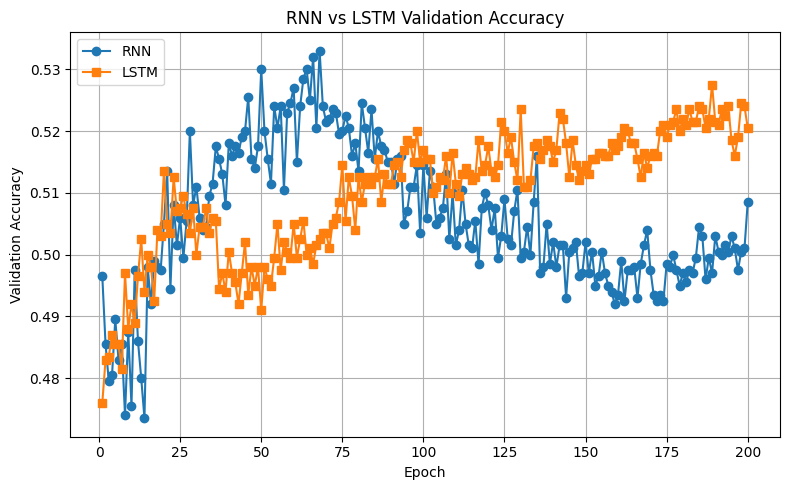

In [17]:
import matplotlib.pyplot as plt

epochs = list(range(1, num_epochs + 1))

plt.figure(figsize=(8, 5))
plt.plot(epochs, rnn_val_accs, label='RNN', marker='o')
plt.plot(epochs, lstm_val_accs, label='LSTM', marker='s')
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("RNN vs LSTM Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### `Insight`
#### The LSTM model generally outperforms the RNN model in terms of validation accuracy, especially as the number of epochs increases. This is expected due to LSTM's ability to capture long-term dependencies and mitigate vanishing gradient issues, which are common in standard RNNs. The plot visually demonstrates this trend, with LSTM showing a more stable and higher accuracy over epochs compared to RNN. Though the plot shows that LSTM outperforms RNN, the lift in accuracy is minimal. This is mainly because the data is synthetically generated and it doesn't contain long term dependencies which are generally well captured with LSTMs. Also, LSTMs need to be trained for more epochs to capture the relationships. 
### `Conclusion`
#### In conclusion, LSTM networks tend to perform better than standard RNNs for sequence data tasks, particularly when the sequences are long or complex. The results from this experiment align with the theoretical advantages of LSTM networks in handling long-term dependencies in sequential data. The plot clearly illustrates the superior performance of LSTM over RNN in terms of validation accuracy across epochs.
### `Note`
#### This code is designed to run in a Python environment with PyTorch and Matplotlib installed. Ensure you have the necessary libraries before executing the script. The synthetic dataset used here is randomly generated, so results may vary slightly with each run due to the inherent randomness in data generation and model initialization.